# Synthetic Probe Analysis — Training

Train logistic-regression probes on JudgementLM internal representations collected
from the **synthetic probe dataset** (`data/{dataset}/probe_dataset.json`).

**Labels**: `label` field in the synthetic dataset (`"valid"` / `"invalid"`)

---

**Part I — Attention Head Probe**  
Score every (layer, head) pair on synthetic 5-fold CV, select the best `TOP_K`
heads by F1, then train a final logistic-regression probe on the full synthetic
training set.  The fitted probe is saved to disk for evaluation in
`synthetic_probe_test.ipynb`.

**Part II — Layer Output Probe (legacy)**  
Score every layer's full residual-stream vector on synthetic 5-fold CV, select
the best layer, and train a final probe.

---

**Metrics reported during CV:** AUROC · F1 · Accuracy

In [1]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

from analysis.loaders import (
    load_synthetic_activations, load_synthetic_layer_outputs, load_synthetic_responses,
)
from scholarlm.utils.probe import grouped_kfold_split, grouped_holdout_split
from scholarlm.utils.calibration import compute_ece
import paths

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.title_fontsize": 9,
    "axes.linewidth": 0.6,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "legend.frameon": False,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.format": "pdf", "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

FIGURES_DIR = "../figures/synthetic_probe/"
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

In [45]:
# ── Parameters ───────────────────────────────────────────────────────────────
DATASET        = 'pond'
JUDGE_MODEL    = 'llama-3.1-8b'   # must match the judge used for the synthetic run
JUDGE_DATE_SYN = '2026_05_04'           # auto-detect latest synthetic probe run

TOP_K   = 32    # number of attention heads for the final probe
N_FOLDS = 5

In [46]:
# Score candidate probes by F1 and ECE
def cv_score(probe, X, y, kfold_cv):
    fold_f1s, fold_eces = [], []
    for train_idx, test_idx in kfold_cv:
        probe.fit(X[train_idx], y[train_idx])
        y_pred = probe.predict(X[test_idx])
        y_true = y[test_idx]
        probs  = probe.predict_proba(X[test_idx])[:, 1]
        fold_f1s.append(f1_score(y_true, y_pred))
        fold_eces.append(compute_ece(probs, y_true, n_bins=10))
    return (
        float(np.mean(fold_f1s)),list(fold_f1s),
        float(np.mean(fold_eces)),list(fold_eces),
    )

## Load Synthetic Data

In [47]:
syn_activations = load_synthetic_activations(DATASET, JUDGE_MODEL, JUDGE_DATE_SYN, split='train')
syn_layer_outputs = load_synthetic_layer_outputs(DATASET, JUDGE_MODEL, JUDGE_DATE_SYN, split='train')
syn_responses   = load_synthetic_responses(DATASET, JUDGE_MODEL, JUDGE_DATE_SYN, split='train')
syn_df          = pd.DataFrame(syn_responses)

syn_measurement_ids = syn_df['measurement_id'].tolist()
syn_labels          = (syn_df['label'] == 'valid').to_numpy(dtype=bool)
syn_groups          = syn_df['document_id'].to_numpy()

print(f'Synthetic activations : {len(syn_activations.files)} entries')
print(f'Synthetic records     : {len(syn_df)}')
print(f'  Valid   : {syn_labels.sum()} ({syn_labels.mean():.1%})')
print(f'  Invalid : {(~syn_labels).sum()} ({(~syn_labels).mean():.1%})')
print(f'Unique papers in synthetic set : {syn_df["document_id"].nunique()}')
print()
print('Modification types:')
print(syn_df['modification_type'].value_counts(dropna=False))

Synthetic activations : 5379 entries
Synthetic records     : 5379
  Valid   : 1793 (33.3%)
  Invalid : 3586 (66.7%)
Unique papers in synthetic set : 48

Modification types:
modification_type
NaN                 1793
table_value          897
change_value         473
noise_value          468
change_entity        467
change_attribute     463
noise_entity         428
change_units         390
Name: count, dtype: int64


In [48]:
# Use all synthetic data for training (no calibration holdout).
# Group-aware split ensures no paper appears in both train and CV test folds.
syn_train_idx, syn_cal_idx, syn_test_idx = grouped_holdout_split(
    syn_groups, train_frac=1.0, cal_frac=0.0, random_state=42
)

# Papers with really really large tables that seem to throw off the activations...
keep_mask = (syn_df.iloc[syn_train_idx]['document_id'] != 'habitat_characteristics') & (syn_df.iloc[syn_train_idx]['document_id'] != 'R164') 
syn_train_idx = syn_train_idx[keep_mask.values]

syn_cv_idx = syn_train_idx
syn_labels_cv = syn_labels[syn_cv_idx]
syn_groups_cv = syn_groups[syn_cv_idx]
kfold_cv = list(grouped_kfold_split(syn_groups_cv, n_splits=N_FOLDS, random_state=42))

print(f'Training set : n={len(syn_train_idx)} ({len(syn_train_idx)/len(syn_labels):.1%})  pos={syn_labels[syn_train_idx].mean():.2%}')
#print(f'Calibration set : n={len(syn_cal_idx)} ({len(syn_cal_idx)/len(syn_labels):.1%})  pos={syn_labels[syn_cal_idx].mean():.2%}')

Training set : n=4914 (91.4%)  pos=33.33%


---
## Part I — Attention Head Probe

Score every (layer, head) pair by F1 on synthetic 5-fold CV, select the best
`TOP_K` heads, then train a final probe on the full synthetic training set and
save it to disk.

## Build Head Feature Matrices

In [49]:
_arr0 = np.array(syn_activations[str(syn_measurement_ids[0])], dtype=np.float32)
n_layers, n_heads, head_dim = _arr0.shape
print(f'Activation shape : n_layers={n_layers}, n_heads={n_heads}, head_dim={head_dim}')
print(f'Total heads      : {n_layers * n_heads}')

print('\nLoading synthetic activations into memory...')
_all_syn = {
    str(mid): np.array(syn_activations[str(mid)], dtype=np.float32)
    for mid in syn_measurement_ids
}
print('Building per-head feature matrices...')
head_datasets_syn: dict[tuple[int, int], np.ndarray] = {}
for l in range(n_layers):
    for h in range(n_heads):
        head_datasets_syn[(l, h)] = np.stack(
            [_all_syn[str(mid)][l, h, :] for mid in syn_measurement_ids], axis=0
        )
del _all_syn
print(f'  Done. Shape: {head_datasets_syn[(0, 0)].shape}')

Activation shape : n_layers=32, n_heads=32, head_dim=128
Total heads      : 1024

Loading synthetic activations into memory...
Building per-head feature matrices...
  Done. Shape: (5379, 128)


## Head Selection (CV on Synthetic Data)

In [50]:
probe_template = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0, class_weight='balanced', solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
])

head_scores_f1    = np.zeros((n_layers, n_heads))
head_scores_ece    = np.zeros((n_layers, n_heads))

print(f'Scoring {n_layers * n_heads} heads on synthetic CV pool (n={len(syn_cv_idx)})...')
for l in range(n_layers):
    for h in range(n_heads):
        X_cv = head_datasets_syn[(l, h)][syn_cv_idx]
        (
         mean_f1, _,
         mean_ece, _,
         ) = cv_score(probe_template, X_cv, syn_labels_cv, kfold_cv)
        head_scores_f1[l, h] = mean_f1
        head_scores_ece[l, h] = mean_ece
    if (l + 1) % 8 == 0:
        print(f'  Layer {l + 1}/{n_layers} done')
print('Done.')

Scoring 1024 heads on synthetic CV pool (n=4914)...
  Layer 8/32 done
  Layer 16/32 done
  Layer 24/32 done
  Layer 32/32 done
Done.


In [71]:
head_scores_f1.max(axis = 1).argmax()

np.int64(30)

In [ ]:
# F1 heatmap:
score_mat = 1 - head_scores_f1
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
im = ax.imshow(np.sort(score_mat, axis=1), cmap='magma', aspect='auto')
ax.set_xlabel('Head (sorted)')
ax.set_ylabel('Layer')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURES_DIR + f'synprobe_heatmap_F1_{DATASET}_{JUDGE_MODEL}.pdf', bbox_inches='tight', dpi=100)

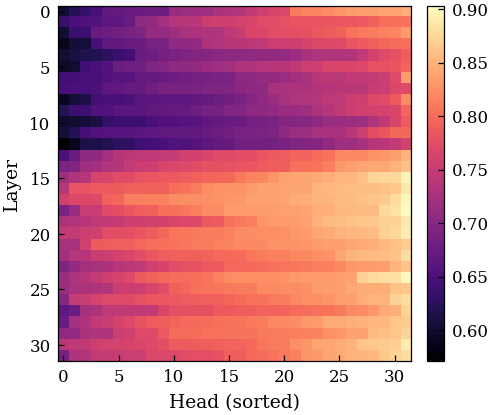

In [85]:
# ECE heatmap:
score_mat = 1 - head_scores_ece
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
im = ax.imshow(np.sort(score_mat, axis=1), cmap='magma', aspect='auto')
ax.set_xlabel('Head (sorted)')
ax.set_ylabel('Layer')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURES_DIR + f'synprobe_heatmap_ECE_{DATASET}_{JUDGE_MODEL}.pdf', bbox_inches='tight', dpi=100)

In [86]:
# Get indices of top 5 by F1
top_f1_idx = np.argpartition(head_scores_f1.flatten(), -TOP_K)[-TOP_K:]
top_f1_coords = [divmod(i, n_heads) for i in top_f1_idx]

# Get indices of top 5 by ECE (lowest is best)
# We flatten, then find the smallest values
top_ece_idx = np.argsort(head_scores_ece.flatten())[:TOP_K]
top_ece_coords = [divmod(i, n_heads) for i in top_ece_idx]

print(f"Top {TOP_K} Heads by F1: {top_f1_coords}")
print(f"Top {TOP_K} Heads by ECE: {top_ece_coords}")

Top 5 Heads by F1: [(np.int64(26), np.int64(22)), (np.int64(18), np.int64(26)), (np.int64(31), np.int64(14)), (np.int64(31), np.int64(12)), (np.int64(30), np.int64(19))]
Top 5 Heads by ECE: [(np.int64(18), np.int64(26)), (np.int64(24), np.int64(27)), (np.int64(17), np.int64(21)), (np.int64(15), np.int64(0)), (np.int64(20), np.int64(26))]


### Visualize Geometry
Using PCA, clustering as a way of semi-manually detecting outliers. The two papers removed from training at the beginning of this notebook were found as very distinct clusters, throwing off the analysis. This is because a significant portion of training samples came from a single page with a very large table. Therefore, a significant portion of the variance in the data can be explained just by indicating if the sample came from this page or not. Visualized, this looks like a small but very distinct cluster. We found that removing this kind of data from the training improved our results.

NOTE: because we removed these earlier, the result here should be (more or less) one continguous cluster-like shape. 

In [60]:
y_train

array([ True,  True,  True, ..., False, False, False], shape=(4914,))

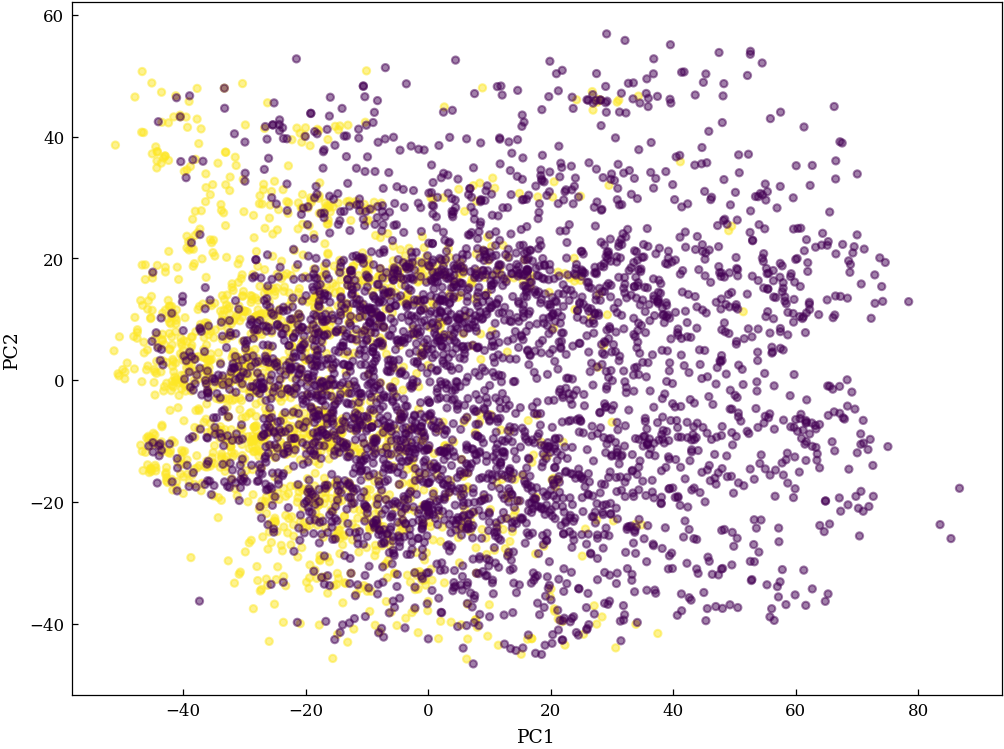

In [64]:
# Sort to top-k heads (by F1):
flat_indices = np.argsort(head_scores_f1.flatten())[-TOP_K:][::-1]
top_k_heads  = [np.unravel_index(idx, head_scores_f1.shape) for idx in flat_indices]

# Dataset:
X_train = np.concatenate(
    [head_datasets_syn[(l, h)][syn_train_idx] for l, h in top_k_heads], axis=1
)
y_train = syn_labels[syn_train_idx]

# PCA:
pipe = Pipeline([
        ('scaler', StandardScaler()),
        #('scaler', FunctionTransformer(per_head_l2_normalize, kw_args={'d': 128})),
        ('pca', PCA(n_components=2)),
])
X_2d = pipe.fit_transform(X_train)

# Clustering
dbscan = DBSCAN(eps=5.0, min_samples=10)
db_clusters = dbscan.fit_predict(X_2d)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, alpha=0.5, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [88]:
# Track which papers, measurements correspond to clusters
print('Cluster 0:')
print(syn_df.iloc[syn_train_idx[(db_clusters == 0)]].loc[:, ['document_id', 'page_number', 'value', 'units', 'label']])
print('Cluster 1:')
print(syn_df.iloc[syn_train_idx[(db_clusters == 1)]].loc[:, ['document_id', 'page_number', 'value', 'units', 'label']])

Cluster 0:
                       document_id page_number   value units    label
0              content_of_selected         [2]     0.8    ha    valid
1              content_of_selected         [3]     0.9    ha    valid
2                global_importance         [1]   0.037  km^2    valid
3                global_importance         [1]  0.0363  km^2    valid
4                global_importance         [1]    0.15  km^2    valid
...                            ...         ...     ...   ...      ...
5372          classification_trees         [4]    20.1  µg/L  invalid
5373           the_legacy_of_large         [3]       4     m  invalid
5374  physical-chemical_influences         [8]   0.333  mg/L  invalid
5376           the_legacy_of_large         [3]       3     m  invalid
5378         impact_of_macrophytes         [4]   156.9  mg/L  invalid

[4914 rows x 5 columns]
Cluster 1:
Empty DataFrame
Columns: [document_id, page_number, value, units, label]
Index: []


### Train Final Probe and Save

Train the final probe on the full synthetic training set using the selected
`TOP_K` heads, then save it to disk.  The saved file includes the fitted probe,
the selected head indices, the training prevalence (for EM rescaling at test
time), and the synthetic document IDs (for filtering at test time).

In [65]:
TOP_K = 16

In [66]:
# Sort to top-k heads (by F1):
flat_indices = np.argsort(head_scores_f1.flatten())[-TOP_K:][::-1]
top_k_heads  = [np.unravel_index(idx, head_scores_f1.shape) for idx in flat_indices]

# Train:
X_train = np.concatenate(
    [head_datasets_syn[(l, h)][syn_train_idx] for l, h in top_k_heads], axis=1
)
y_train = syn_labels[syn_train_idx]

base_probe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=0.5, class_weight=None, solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
])

calibrated_probe = CalibratedClassifierCV(
    estimator=base_probe,
    method='sigmoid',  # 'sigmoid' is Platt scaling
    cv=kfold_cv
).fit(X_train, y_train)

# Evaluate training performance:
y_probs = calibrated_probe.predict_proba(X_train)[:, 1]
y_pred = (y_probs > 0.5).astype(int)
print(f"  Accuracy  : {accuracy_score(y_train, y_pred):.4f}")
print(f"  Precision : {precision_score(y_train, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_train, y_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_train, y_pred):.4f}")
print(f"  AUROC     : {roc_auc_score(y_train, y_probs):.4f}")
print(f"  ECE       : {compute_ece(y_train, y_probs):.4f}")


# Save probe + metadata for use in synthetic_probe_test.ipynb
probe_dir  = paths.trained_probe_dir(DATASET, JUDGE_MODEL)
probe_dir.mkdir(parents=True, exist_ok=True)
probe_path = probe_dir / 'head_probe.pkl'

probe_data = {
    'probe':            calibrated_probe,
    'top_k_heads':      top_k_heads,
    'train_prevalence': float(y_train.mean()),
    'syn_document_ids': sorted(syn_df['document_id'].unique().tolist()),
    'judge_model':      JUDGE_MODEL,
    'dataset':          DATASET,
    'n_layers':         n_layers,
    'n_heads':          n_heads,
    'head_dim':         head_dim,
}
joblib.dump(probe_data, probe_path)

print(f'Probe saved  → {probe_path}')
print(f'  Top-{TOP_K} heads        : {top_k_heads}')

  Accuracy  : 0.9552
  Precision : 0.9398
  Recall    : 0.9249
  F1-Score  : 0.9323
  AUROC     : 0.9928
  ECE       : 0.2533
Probe saved  → /projectnb/mcnet/kevin/coastal/scholarlm/data/experiments/pond/synthetic_probe/llama-3.1-8b/trained_probe/head_probe.pkl
  Top-16 heads        : [(np.int64(30), np.int64(19)), (np.int64(31), np.int64(12)), (np.int64(31), np.int64(14)), (np.int64(18), np.int64(26)), (np.int64(26), np.int64(22)), (np.int64(15), np.int64(0)), (np.int64(19), np.int64(7)), (np.int64(16), np.int64(17)), (np.int64(31), np.int64(15)), (np.int64(31), np.int64(31)), (np.int64(31), np.int64(28)), (np.int64(26), np.int64(20)), (np.int64(31), np.int64(6)), (np.int64(15), np.int64(9)), (np.int64(17), np.int64(3)), (np.int64(30), np.int64(10))]


---
## Part II — Layer Output Probe (legacy)

Repeat the same CV → train protocol using the full residual-stream vector at
each layer (shape: `n_layers × hidden_size`) instead of individual attention
heads.  The best layer is selected by CV F1 and a final probe is trained on
the full synthetic training set.

### Build Layer Feature Matrices

In [39]:
_arr0_lo = np.array(syn_layer_outputs[str(syn_measurement_ids[0])], dtype=np.float32)
n_layers_lo, hidden_size = _arr0_lo.shape
print(f'Layer output shape : n_layers={n_layers_lo}, hidden_size={hidden_size}')

print('\nBuilding per-layer feature matrices (synthetic)...')
_all_syn_lo = {str(mid): np.array(syn_layer_outputs[str(mid)], dtype=np.float32)
               for mid in syn_measurement_ids}
layer_datasets_syn: dict[int, np.ndarray] = {
    l: np.stack([_all_syn_lo[str(mid)][l] for mid in syn_measurement_ids], axis=0)
    for l in range(n_layers_lo)
}
del _all_syn_lo
print(f'  Done. Shape: {layer_datasets_syn[0].shape}')

Layer output shape : n_layers=28, hidden_size=3584

Building per-layer feature matrices (synthetic)...
  Done. Shape: (5379, 3584)


### Layer Selection via Cross-Validation

In [40]:
probe_template_lo = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=0.2, class_weight='balanced', solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
])

layer_scores_f1    = np.zeros(n_layers_lo)
layer_scores_ece = np.zeros(n_layers_lo)

print(f'Scoring {n_layers_lo} layers on synthetic CV pool (n={len(syn_cv_idx)})...')
for l in range(n_layers_lo):
    X_cv = layer_datasets_syn[l][syn_cv_idx]
    (
         mean_f1, _,
         mean_ece, _,
         ) = cv_score(probe_template_lo, X_cv, syn_labels_cv, kfold_cv)
    layer_scores_f1[l]    = mean_f1
    layer_scores_ece[l] = mean_ece
    if (l + 1) % 8 == 0:
        print(f'  Layer {l + 1}/{n_layers_lo} done')
print('Done.')

Scoring 28 layers on synthetic CV pool (n=4914)...
  Layer 8/28 done
  Layer 16/28 done
  Layer 24/28 done
Done.


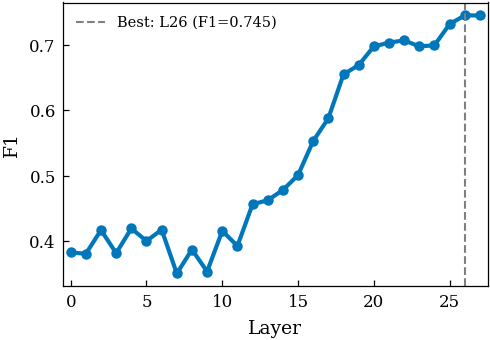

In [41]:
# F1 by layer line plot — layer output probe
best_layer_lo = int(layer_scores_f1.argmax())
fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.plot(range(n_layers_lo), layer_scores_f1, 'o-', color='#0077BB', ms=4, lw = 2.0)
ax.axvline(best_layer_lo, color="grey", lw=1.0, ls='--', label=f'Best: L{best_layer_lo} (F1={layer_scores_f1[best_layer_lo]:.3f})')
ax.set_xlabel('Layer')
ax.set_ylabel('F1')
ax.legend(fontsize=7)
ax.set_xlim(-0.5, n_layers_lo - 0.5)
fig.tight_layout()
fig.savefig(FIGURES_DIR + f'synprobe_layer_F1_{DATASET}_{JUDGE_MODEL}.pdf', bbox_inches='tight')

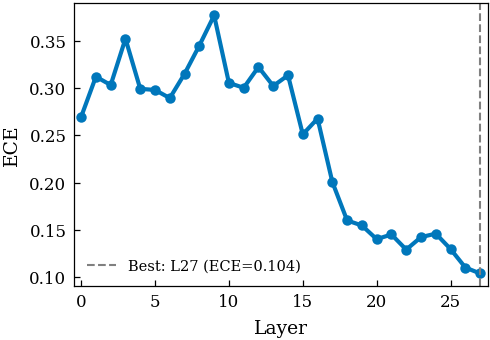

In [42]:
# ECE by layer line plot — layer output probe
best_layer_lo = int(layer_scores_ece.argmin())
fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.plot(range(n_layers_lo), layer_scores_ece, 'o-', color='#0077BB', ms=4, lw = 2.0)
ax.axvline(best_layer_lo, color='grey', lw=1.0, ls='--', label=f'Best: L{best_layer_lo} (ECE={layer_scores_ece[best_layer_lo]:.3f})')
ax.set_xlabel('Layer')
ax.set_ylabel('ECE')
ax.legend(fontsize=7)
ax.set_xlim(-0.5, n_layers_lo - 0.5)
fig.tight_layout()
fig.savefig(FIGURES_DIR + f'synprobe_layer_ECE_{DATASET}_{JUDGE_MODEL}.pdf', bbox_inches='tight')

### Train Final Layer Probe

In [44]:
best_layer_lo = int(layer_scores_f1.argmax())
X_train_lo = layer_datasets_syn[best_layer_lo][syn_train_idx]
y_train_lo = syn_labels[syn_train_idx]

base_probe_lo = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.2, class_weight=None, solver='lbfgs',
                               max_iter=1000, random_state=42))
])


calibrated_probe_lo = CalibratedClassifierCV(
    estimator=base_probe_lo,
    method='sigmoid',  # 'sigmoid' is Platt scaling
    cv=kfold_cv
).fit(X_train_lo, y_train_lo)

# Evaluate training performance:
y_probs_lo = calibrated_probe_lo.predict_proba(X_train_lo)[:, 1]
y_pred_lo = (y_probs_lo > 0.5).astype(int)
print(f"  Accuracy  : {accuracy_score(y_train_lo, y_pred_lo):.4f}")
print(f"  Precision : {precision_score(y_train_lo, y_pred_lo):.4f}")
print(f"  Recall    : {recall_score(y_train_lo, y_pred_lo):.4f}")
print(f"  F1-Score  : {f1_score(y_train_lo, y_pred_lo):.4f}")
print(f"  AUROC     : {roc_auc_score(y_train_lo, y_probs_lo):.4f}")
print(f"  ECE       : {compute_ece(y_train_lo, y_probs_lo):.4f}")

# Save probe + metadata for use in synthetic_probe_test.ipynb
probe_dir  = paths.trained_probe_dir(DATASET, JUDGE_MODEL)
probe_dir.mkdir(parents=True, exist_ok=True)
probe_path = probe_dir / 'layer_probe.pkl'

probe_data = {
    'probe':            calibrated_probe_lo,
    'top_layer':      best_layer_lo,
    'train_prevalence': float(y_train_lo.mean()),
    'syn_document_ids': sorted(syn_df['document_id'].unique().tolist()),
    'judge_model':      JUDGE_MODEL,
    'dataset':          DATASET,
    'n_layers':         n_layers_lo,
}
joblib.dump(probe_data, probe_path)

print(f'Probe saved  → {probe_path}')
print(f'Top layer: {best_layer_lo}')

  Accuracy  : 0.9483
  Precision : 0.8972
  Recall    : 0.9542
  F1-Score  : 0.9249
  AUROC     : 0.9903
  ECE       : 0.1891
Probe saved  → /projectnb/mcnet/kevin/coastal/scholarlm/data/experiments/pond/synthetic_probe/qwen-2.5-7b/trained_probe/layer_probe.pkl
Top layer: 26


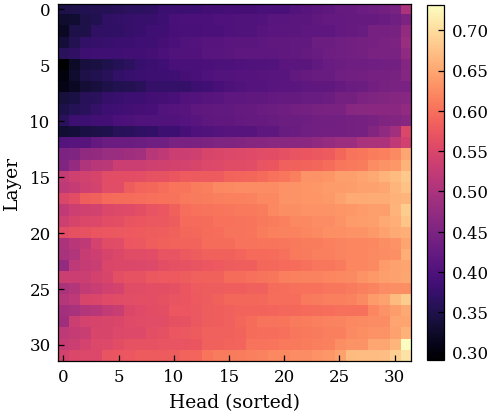

In [84]:
# F1 heatmap:
score_mat = head_scores_f1
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
im = ax.imshow(np.sort(score_mat, axis=1), cmap='magma', aspect='auto')
ax.set_xlabel('Head (sorted)')
ax.set_ylabel('Layer')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURES_DIR + f'synprobe_heatmap_F1_{DATASET}_{JUDGE_MODEL}.pdf', bbox_inches='tight', dpi=100)